In [1]:
import torch
from gpt_model import GPTModel
GPT_CONFIG_124M = {
"vocab_size": 50257,
"context_length": 256,
"emb_dim": 768,
"n_heads": 12,
"n_layers": 12,
"drop_rate": 0.1,
"qkv_bias": False
}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
model.eval()

GPTModel(
  (token_embeddings): Embedding(50257, 768)
  (position_embeddings): Embedding(256, 768)
  (drop_embeddings): Dropout(p=0.1, inplace=False)
  (transformer_blocks): Sequential(
    (0): TransformerBlock(
      (transformer): MultiHeadAttention(
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (feed_forward): FeedForwardNetwork(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNormalization()
      (norm2): LayerNormalization()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )


In [3]:
import os
import urllib.request
file_path = "the-verdict.txt"
url = ("https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/""main/ch02/01_main-chapter-code/the-verdict.txt")
if not os.path.exists(file_path):
    with urllib.request.urlopen(url ) as response:
        text_data= response.read().decode('utf-8')
    with open (file_path, 'w', encoding='utf-8') as file:
        file.write(text_data)

else:
    with open(file_path, "r", encoding="utf-8") as file:
        text_data = file.read()
        


In [4]:
from dataloader_v1 import create_dataloader_v1
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
torch.manual_seed(123)
train_loader = create_dataloader_v1(text_data[:split_idx],batch_size=2,max_length=GPT_CONFIG_124M["context_length"],stride=GPT_CONFIG_124M["context_length"],drop_last=True,shuffle=True,num_workers=0)
val_loader = create_dataloader_v1(
text_data[split_idx:],
batch_size=2,
max_length=GPT_CONFIG_124M["context_length"],
stride=GPT_CONFIG_124M["context_length"],
drop_last=False,
shuffle=False,
num_workers=0
)

### Learning rate warmup

Implementing a learning rate warmup can stabilize the training of complex models
such as LLMs. This process involves gradually increasing the learning rate from a very
low initial value (initial_lr) to a maximum value specified by the user (peak_lr).
Starting the training with smaller weight updates decreases the risk of the model
encountering large, destabilizing updates during its training phase.

In [6]:
num_epochs=15
initial_lr=0.0001
peak_lr= 0.01
warmup_steps=20
total_steps= len(train_loader) * num_epochs
print(total_steps)
warmup_steps = int(0.2 * total_steps)
print(warmup_steps)

120
24


In [8]:
optimizer = torch.optim.AdamW(model.parameters(), weight_decay=0.1)
lr_increment= (peak_lr- initial_lr) / warmup_steps
global_step=-1
track_lrs=[]

for epoch in range(num_epochs):
    for input_batch, target_batch in train_loader:
        optimizer.zero_grad()
        global_step += 1
        if global_step < warmup_steps:
            lr = initial_lr + global_step * lr_increment
        else:
            lr = peak_lr
        for param_group in optimizer.param_groups:
            param_group["lr"] = lr
        track_lrs.append(optimizer.param_groups[0]["lr"])

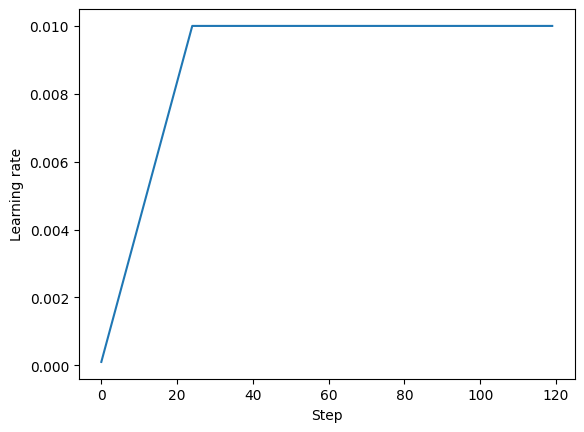

In [9]:
import matplotlib.pyplot as plt
plt.ylabel("Learning rate")
plt.xlabel("Step")
total_training_steps = len(train_loader) * num_epochs
plt.plot(range(total_training_steps), track_lrs);
plt.show()
